### Постановка задачи

**Задание**
1. Выберите наиболее релевантную выборку пользователей для проведения
анализа.
2. Для каждого пользователя рассчитайте Recency, Frequency, Monetary по
описанному выше алгоритму.
3. Дайте оценку RFM. Сгруппируйте пользователей по категориям.
4. Постройте графики и сделайте выводы.

**Таблица data:**
* InvoiceNo – номер заказа
* StockCode – код акции
* Description – название акции
* Quantity – количество единиц товара в заказе
* InvoiceDate – дата заказа
* UnitPrice – цена единицы товара
* CustomerID – идентификатор пользователя
* Country – страна

### Загрузка и первичная обработка данных

In [380]:
pip install squarify

Note: you may need to restart the kernel to use updated packages.


In [109]:
import pandas as pd
import os 
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns 

In [45]:
# загрузка данных - у всех одинаковая
os.chdir(r'C:\Users\pasht\OneDrive\Документы\4 курс 1 семестр\прикладная аналитика\практическая 7')
df = pd.read_csv('data.csv', encoding="ISO-8859-1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [67]:
#выведите описательные статистики датасета
print(df.describe(), '\nДлина датасета:', df.shape[0], '\nПропущенные значения:\n', df.isna().sum())

            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000       4.130000   16791.000000
max     80995.000000   38970.000000   18287.000000 
Длина датасета: 541909 
Пропущенные значения:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [73]:
#удалим NaN 
clean_df = df.dropna(subset = ['CustomerID']) #удалим наны только по юзер айди, 
#потому что у нас наны есть только в этом столбце и в названии акции, а отсутствие названия акции не помешает провести  RFM-сегментацию
clean_df.shape[0]

406829

In [75]:
#Удалим отрицательные значения
clean_df = clean_df[(clean_df['Quantity'] >= 0) & (clean_df['UnitPrice'] >= 0) & (clean_df['CustomerID'] >= 0)] 
clean_df.shape[0]

397924

In [81]:
clean_df.describe()

,Quantity,UnitPrice,CustomerID
count,397924.000000,397924.000000,397924.000000
mean,13.021823,3.116174,15294.315171
std,180.420210,22.096788,1713.169877
min,1.000000,0.000000,12346.000000
25%,2.000000,1.250000,13969.000000
50%,6.000000,1.950000,15159.000000
75%,12.000000,3.750000,16795.000000
max,80995.000000,8142.750000,18287.000000


### RFM - сегментация

In [93]:
#есть подозрения что кол-во и распределение данных по странам несопоставими и их нельзя брать вместе
clean_df['Country'].value_counts()

Country
United Kingdom          354345
Germany                   9042
France                    8342
EIRE                      7238
Spain                     2485
Netherlands               2363
Belgium                   2031
Switzerland               1842
Portugal                  1462
Australia                 1185
Norway                    1072
Italy                      758
Channel Islands            748
Finland                    685
Cyprus                     614
Sweden                     451
Austria                    398
Denmark                    380
Poland                     330
Japan                      321
Israel                     248
Unspecified                244
Singapore                  222
Iceland                    182
USA                        179
Canada                     151
Greece                     145
Malta                      112
United Arab Emirates        68
European Community          60
RSA                         58
Lebanon                     45


In [95]:
#посмотрим на средний чек и количество покупок по странам
country_df = clean_df.groupby('Country').agg({'UnitPrice':'mean', 'Quantity':'mean'}) 
country_df

,UnitPrice,Quantity
Country,,
Australia,3.048523,71.062447
Austria,4.256030,12.263819
Bahrain,4.644118,15.294118
Belgium,3.630158,11.441162
Brazil,4.456250,11.125000
Canada,6.030331,18.298013
Channel Islands,4.531618,12.688503
Cyprus,5.710391,10.359935
Czech Republic,3.130800,26.840000


### Делать RFM сегментацию по всем странам некорректно: у нас гигантский перекос — United Kingdom составляет около 78% всех заказов (354k из ~450k), а значит сегментация по всем странам будет просто RFM по британцам с шумом вокруг. Также очень важно, что остальные страны сильно отличаются по средним чекам (например, Singapore со средним UnitPrice 58 против UK, где средний UnitPrice 2,96) их нельзя сравнивать напрямую.

### Поэтому мы будем делать RFM только по United Kingdom — там больше всего данных

In [160]:
#выберите релевантную выборку (выбрать пользователей по какому-то качественному признаку, исходя из цели RFM-анализа, которую Вы сформулируете)
df_sample = clean_df[clean_df['Country'] == 'United Kingdom']
df_sample.shape

(354345, 8)

In [127]:
df_sample.describe()

,Quantity,UnitPrice,CustomerID
count,354345.000000,354345.000000,354345.000000
mean,12.048913,2.963793,15552.436219
std,190.428127,17.862067,1594.546025
min,1.000000,0.000000,12346.000000
25%,2.000000,1.250000,14194.000000
50%,4.000000,1.950000,15522.000000
75%,12.000000,3.750000,16931.000000
max,80995.000000,8142.750000,18287.000000


In [156]:
df_sample_price_zero = df_sample.query('UnitPrice == 0') 
df_sample_quantity_zero = df_sample.query('Quantity == 0') 
df_sample_price_zero.shape
#df_sample_quantity_zero.shape

(0, 8)

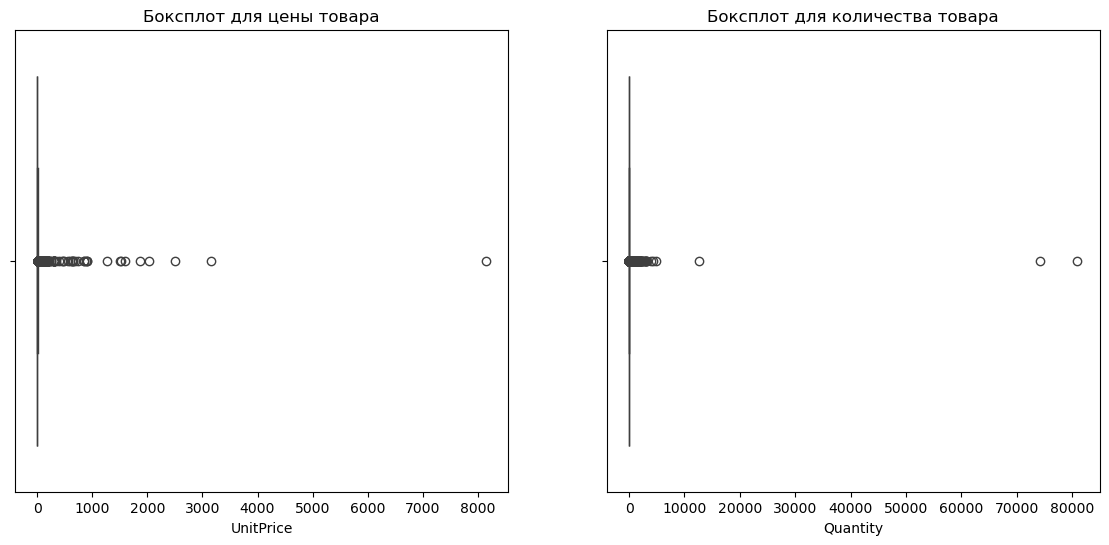

In [162]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df_sample, x='UnitPrice', ax=axes[0])
axes[0].set_title('Боксплот для цены товара')

sns.boxplot(data=df_sample, x='Quantity', ax=axes[1])
axes[1].set_title('Боксплот для количества товара')

plt.show()

### У нас есть несколько очевидных аномалий, но мы НЕ ликвидируем их, потому, что, возможно это реальные данные, проверить мы их не можем, но т.к. на сегменты мы будем разбивать с помощью квантилей, они значимо не испортят результат

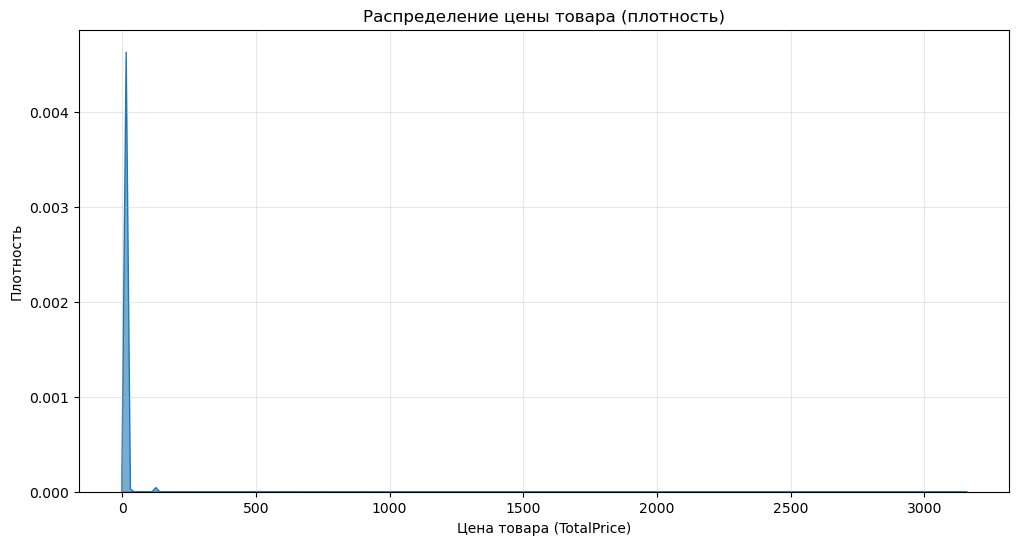

In [170]:
# посмотрим распределение цены товара и кол-ва заказов
plt.figure(figsize=(12, 6))
sns.kdeplot(df_sample['UnitPrice'],fill = True,  alpha=0.6)
plt.title('Распределение цены товара (плотность)')
plt.xlabel('Цена товара (TotalPrice)')
plt.ylabel('Плотность')
plt.grid(True, alpha=0.3)
plt.show()

In [168]:
#посчитайте выручку, это необходимо для Monetary
df_sample['Revenue'] = df_sample['Quantity']*df_sample['UnitPrice']

In [192]:
#сделаем удобный формат даты
df_sample['InvoiceDate'] = pd.to_datetime(df_sample['InvoiceDate']).dt.normalize()
print(df_sample['InvoiceDate'].dtype)

datetime64[ns]


In [226]:
#готовим данные для RFM
data_forRFM = df_sample.groupby('CustomerID', as_index=False).agg({'Revenue': 'sum', 'InvoiceDate':'max', 'InvoiceNo':'count'})

data_forRFM = data_forRFM.rename(columns={
    'Revenue': 'Monetary',
    'InvoiceDate': 'MaxDate',
    'InvoiceNo': 'Frequency'
})
data_forRFM[:3]

,CustomerID,Monetary,MaxDate,Frequency
0,12747.0,4196.01,2011-12-07,103
1,12748.0,33719.73,2011-12-09,4596
2,12749.0,4090.88,2011-12-06,199


In [254]:
#рассчитаем показатель Recency (давность)
#найдите последнюю (максимальную) дату  покупки (надо работать со столбцом InvoiceDate)
max_date = data_forRFM['MaxDate'].max()
data_forRFM['Recency'] = (max_date - data_forRFM['MaxDate']).dt.days
data_forRFM.sort_values(by = 'Recency', ascending = False, inplace = True)
data_forRFM[:3]

,CustomerID,Monetary,MaxDate,Frequency,Recency
1003,14237.0,161.00,2010-12-01,9,373
1661,15165.0,487.75,2010-12-01,27,373
174,13065.0,205.86,2010-12-01,14,373


<Axes: xlabel='Frequency'>

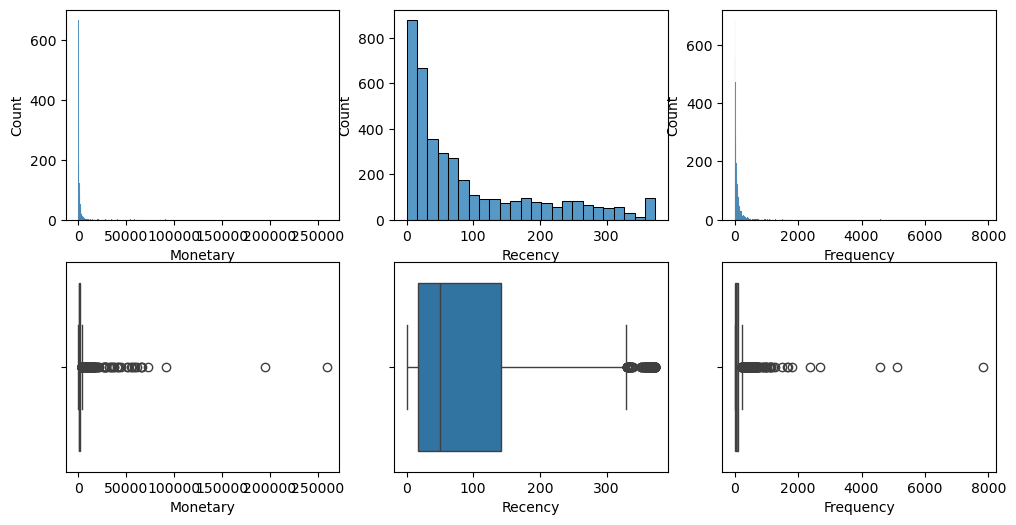

In [270]:
fig, axes = plt.subplots(2,3, figsize = (12, 6))
sns.histplot(data = data_forRFM, x = 'Monetary', ax = axes[0,0])
sns.histplot(data = data_forRFM, x = 'Recency', ax = axes[0,1])
sns.histplot(data = data_forRFM, x = 'Frequency', ax = axes[0,2])
sns.boxplot(data = data_forRFM, x = 'Monetary', ax = axes[1,0])
sns.boxplot(data = data_forRFM, x = 'Recency', ax = axes[1,1])
sns.boxplot(data = data_forRFM, x = 'Frequency', ax = axes[1,2])

### Полученные Monetary, Recency и Frequency сильно перекошены, но это нормально

In [279]:
data_forRFM.describe()

,CustomerID,Monetary,MaxDate,Frequency,Recency
count,3919.000000,3919.000000,3919,3919.000000,3919.000000
mean,15562.880327,1800.100945,2011-09-08 06:21:46.251595008,90.416178,91.734881
min,12747.000000,2.900000,2010-12-01 00:00:00,1.000000,0.000000
25%,14209.500000,300.030000,2011-07-20 00:00:00,17.000000,17.000000
50%,15570.000000,650.510000,2011-10-20 00:00:00,41.000000,50.000000
75%,16913.500000,1574.180000,2011-11-22 00:00:00,99.500000,142.000000
max,18287.000000,259657.300000,2011-12-09 00:00:00,7847.000000,373.000000
std,1575.958319,6867.223035,NaN,217.842300,99.482068


### Так как у нас не нормальное распределение, а правосторонняя ассиметрия, мы будем использовать разбиение на группы по квантилям для Recency 50%/30%/20%, а для Monetary и Frequency 60%/30%/10%, потому что у них степерь скошенности гораздо выше

In [298]:
data_forRFM['Monetary_score'] = pd.qcut(x=data_forRFM['Monetary'], q = [0, 0.6,  0.90, 1], labels = ['3', '2', '1'])
data_forRFM['Frequency_score'] = pd.qcut(x=data_forRFM['Frequency'], q = [0, 0.6,  0.90, 1], labels = ['3', '2', '1'])
data_forRFM['Recency_score'] = pd.qcut(x=data_forRFM['Recency'], q = [0, 0.5,  0.80, 1], labels = ['1', '2', '3'])

In [310]:
#Проверим, что все получилось
print(data_forRFM['Monetary_score'].value_counts(), data_forRFM['Frequency_score'].value_counts(), data_forRFM['Recency_score'].value_counts())

Monetary_score
3    2351
2    1176
1     392
Name: count, dtype: int64 Frequency_score
3    2369
2    1159
1     391
Name: count, dtype: int64 Recency_score
1    1971
2    1165
3     783
Name: count, dtype: int64


In [322]:
data_forRFM['RFM'] = data_forRFM['Recency_score'].astype('str')+data_forRFM['Frequency_score'].astype('str')+\
data_forRFM['Monetary_score'].astype('str')
#посмотрим кол-во клиентов в группе 111 
data_forRFM['RFM'].value_counts()['111']

216

In [368]:
#посчитаем кол-во пользователей в каждой группе  
group_counts = data_forRFM.groupby('RFM', as_index = False).agg({'CustomerID':'count'})
group_counts.rename(columns = {'CustomerID':'Count_of_customers'}, inplace = True)
group_counts.sort_values(by = 'Count_of_customers', ascending = False, inplace = True)
group_counts[:3]

,RFM,Count_of_customers
17,233,694
25,333,666
8,133,657


Text(0.5, 1.0, 'Распределение клиентов по RFM-группам (с процентами)')

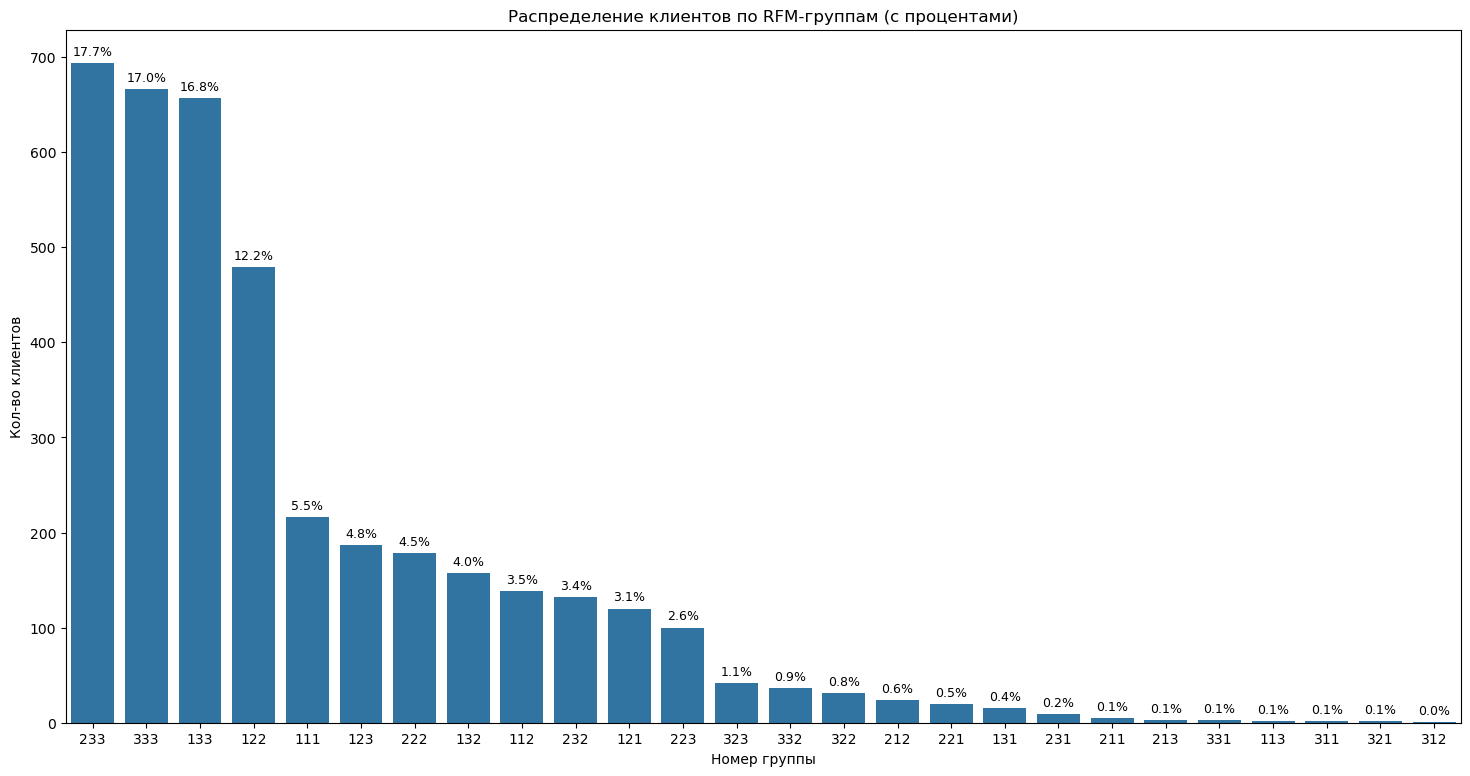

In [376]:
#визуализация

total_customers = group_counts['Count_of_customers'].sum()

plt.figure(figsize = (18,9))
ax = sns.barplot(data = group_counts, x = 'RFM', y = 'Count_of_customers')

#добавим подписи (процент группы от всех покупателей)
for i, row in enumerate(group_counts.itertuples()):
    percent = (row.Count_of_customers / total_customers) * 100
    ax.text(i, row.Count_of_customers + 5, f'{percent:.1f}%', ha='center', va='bottom', fontsize=9, color='black')
    
plt.xlabel('Номер группы')
plt.ylabel('Кол-во клиентов')
plt.title('Распределение клиентов по RFM-группам (с процентами)')

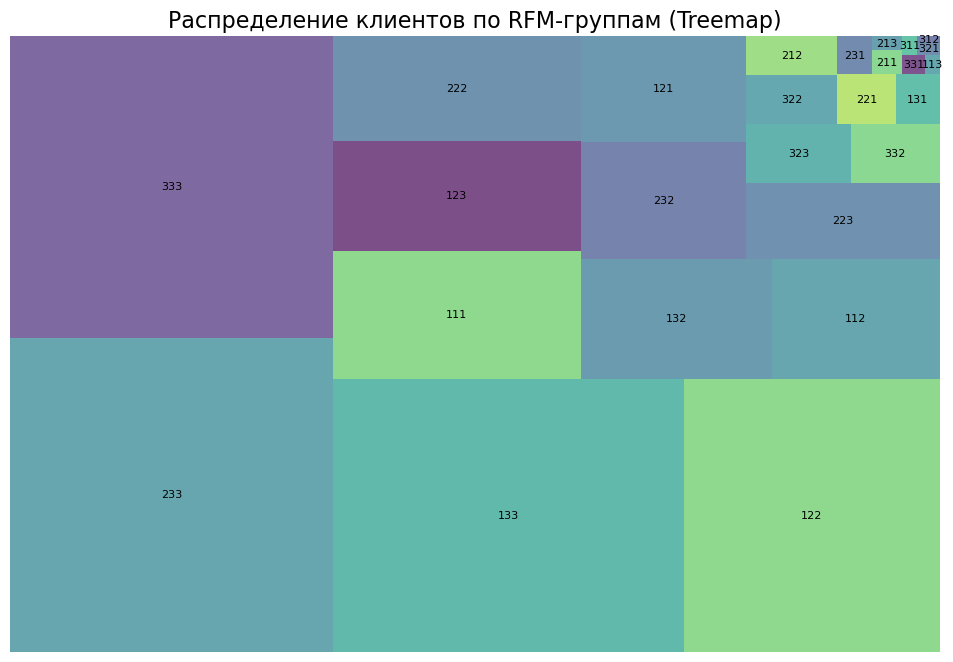

In [384]:
import matplotlib.pyplot as plt
import squarify

# Рисуем treemap
plt.figure(figsize=(12, 8))
squarify.plot(sizes=group_counts['Count_of_customers'], label=group_counts['RFM'], alpha=0.7, text_kwargs={'fontsize':8})

plt.title('Распределение клиентов по RFM-группам (Treemap)', fontsize=16)
plt.axis('off')  # убираем оси — они тут не нужны
plt.show()

### Выводы по анализу:
### Большая часть клиентской базы — 63,7% — сосредоточена в 4 группах (233 - средней давности, редкие с низким чеком; 333 - худшие клиенты, давние, редкие и с низким чеком , 133 - недавние, но редкие и с низким чеком , 122 - недавние, не очень частые, со средним чеком). Остальные 23 группы - оставшиеся 36,3%.  Бизнесу нужно обратить особое внимание на сегменты 122 и 133, поскольку они объединяют клиентов с низкой давностью последней покупки — признак потенциальной лояльности — но ограничены по частоте или размеру чека. Эти группы представляют собой скрытый ресурс для роста: их можно стимулировать через персонализированные предложения, повышающие частоту или средний чек, что позволит перевести их в более ценные категории (например, 112 или 111). В то же время сегменты 233 и 333, несмотря на свою численность, характеризуются низкой активностью и вкладом в выручку, что делает их менее приоритетными для инвестиций в маркетинговые усилия.. 

### При этом наиболее ценные клиенты — группа 111 (высокая давность, частые покупки, крупные чеки) — составляют около 5,5% от общего числа. Эта группа представляет собой стратегически важный сегмент — наиболее лояльных и высокодоходных клиентов, характеризующихся недавностью последней покупки, высокой частотой транзакций и значительным средним чеком. Ввиду их критической роли в генерации выручки, бизнес должен сосредоточить на них максимальные ресурсы по удержанию: внедрять персонализированные программы лояльности, предоставлять эксклюзивные привилегии и обеспечивать премиальное обслуживание, чтобы минимизировать риск оттока и максимизировать долгосрочную ценность этих клиентов.Клиенты с двумя единицами (например, 112, 113, 121, 131) — потенциально лояльные и активные — также представлены ограниченно, суммарно занимая менее 10% базы. Их можно рассматривать как приоритетную аудиторию для программ удержания и перехода в статус VIP. Таким образом, основная выручка генерируется небольшой долей клиентов, что требует особого внимания к персонализированному взаимодействию с высокозначимыми сегментами.

